<a href="https://colab.research.google.com/github/andandandand/practical-computer-vision/blob/main/notebooks/Bo_or_Not_Bo_VGG16_and_FiftyOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning and Fine-tuning with FiftyOne and PyTorch: From an Imagenet-pretrained VGG16 to a Custom Binary Classifier of Dog Breeds

### author: [Antonio Rueda-Toicen](antonio@getfiftyone.com)

[![Creative Commons License](https://i.creativecommons.org/l/by/4.0/88x31.png)](http://creativecommons.org/licenses/by/4.0/)

This work is licensed under a [Creative Commons Attribution 4.0 International License](http://creativecommons.org/licenses/by/4.0/).


## Introduction
In the past years, transfer learning and the fine-tuning of pre-trained models have become important techniques that changed how we approach computer vision problems. Rather than training neural networks from scratch (a process that often requires large datasets, substantial computational resources, and long periods of training time) modern practitioners often leverage the power of pre-trained models that have already learned to recognize fundamental visual patterns from large datasets.

This shift represents a democratization of advanced AI capabilities. Where once only organizations with access to vast datasets and computational infrastructure could build sophisticated computer vision systems, transfer learning enables small teams and individual practitioners to achieve state-of-the-art results on custom problems with limited data and computational resources.

The core insight is elegant: visual features learned from one task often generalize remarkably well to others. A model trained to distinguish between thousands of ImageNet categories has already learned to detect edges, textures, shapes, and complex object parts. These are the building blocks needed for most computer vision tasks. By starting with these learned representations and adapting them to our specific problem, we can achieve better performance with less data and training time than starting from scratch.

This blog post demonstrates how to leverage pre-trained models from the FiftyOne Model Zoo to solve a custom binary classification problem. We'll walk through a complete workflow that teaches you not just the "how" but also the "why" behind each decision, showing how transfer learning and fine-tuning fit into modern deep learning practice.

This solution is one of the concepts that we explore in [NVIDIA's Fundamentals of Deep Learning Course]().


**What you'll learn:**

- The fundamentals of transfer learning and how to use them
- How to work with FiftyOne for dataset management, augmentation, and visualization
- Practical implementation of VGG16 for custom classification tasks
- Identifying data leakage with embeddings
- Training strategies and evaluation techniques


### Prerequisites for This Tutorial

To get the most out of this guide, you should have a basic understanding of the following:

*   **Python Programming:** Familiarity with Python syntax, data structures (lists, dictionaries), and functions.
*   **Fundamental Machine Learning Concepts:** A basic grasp of what training, validation, and testing mean, as well as concepts like overfitting.
*   **PyTorch Basics:**
    *   Understanding of Tensors.
    *   How to build a simple neural network with `torch.nn`.
    *   Familiarity with the concepts of a `Dataset` and `DataLoader`.
    *   Knowledge of a basic training loop (forward pass, loss calculation, backpropagation, optimizer step).
*   **Convolutional Neural Networks (CNNs):** [A high-level understanding of what CNNs are](https://youtu.be/M-YWxCUvmnI?si=Zh3WFdmAHpXeABdE) and the roles of convolutional and fully-connected layers.
*   **Jupyter Notebooks / Google Colab:** Experience running code in a cell-based notebook environment.


## Meet Bo

Bo [was Barack Obama's dog](https://en.wikipedia.org/wiki/Bo_(dog). He was a Portuguese Water Dog.

![](https://i.guim.co.uk/img/media/d702b3c7f292dd26baf23d01b07eac85bdf6addb/0_46_665_399/master/665.jpg?width=700&quality=85&auto=format&fit=max&s=6a96387dcd37d0579571db8a91170349)

Imagine that the secret service wanted at some point in time to create a computer vision system to automatically recognize him (actually, his breed) from other pets.

We will take that task and use it to explore [transfer learning](https://developers.google.com/machine-learning/glossary#transfer-learning).


## VGG16 and ImageNet

![](https://miro.medium.com/v2/resize:fit:827/1*UeAhoKM0kJfCPA03wt5H0A.png)

[VGG16](https://arxiv.org/abs/1409.1556) is a [convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN) architecture that was introduced by the Visual Geometry Group (VGG) at the University of Oxford.

The "16" in VGG16 refers to the number of learnable [layers](https://developers.google.com/machine-learning/glossary#layer) in the network architecture. These layers include convolutional layers and fully connected layers. It does not count the [pooling layers](https://developers.google.com/machine-learning/glossary#pooling) or [activation functions](https://developers.google.com/machine-learning/glossary#activation_function).

It is known for its simplicity and its use of a stack of small 3x3 convolutional layers, followed by pooling and fully connected layers. [ImageNet](https://www.image-net.org/) is a large-scale dataset of images that is used for training and benchmarking computer vision models. It contains millions of labeled images across thousands of categories. VGG16 was originally trained on the ImageNet dataset, which means it learned to recognize a wide variety of objects and scenes. This pre-training on a large dataset like ImageNet makes VGG16 a powerful feature extractor that can be used for transfer learning on new image classification tasks.

We will use a VGG16 ImageNet-pretrained convolutional network to classify our pet images. We will first explore what the network knows, then we will adapt its architecture to the binary classification task of figuring out whether a pet image is Bo or not.


### What is Transfer Learning?

Transfer learning is one of the most powerful techniques in modern deep learning. Instead of training a neural network from scratch, we take a model that has already been trained on a large dataset and adapt it to our specific problem.

Imagine you're learning to drive a motorcycle after already knowing how to drive a car. You don't start from zero: you transfer your knowledge of traffic rules, spatial awareness, and vehicle control to the new context.

### The ImageNet-1K Foundation

ImageNet-1K is one of the most important datasets in the field of computer vision and machine learning. It is a subset of the larger [ImageNet database](https://www.image-net.org/), which contains over 14 million hand-annotated images. ImageNet-1K, specifically, is known for its use in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) and has become a standard benchmark for training and evaluating image classification models. When the [AlexNet model](https://docs.voxel51.com/model_zoo/models.html#alexnet-imagenet-torch) won the ImageNet-1K classification challenge, the current wave of excitement around deep learning started.

The dataset is substantial in size, it has:

*   **Over 1.2 million training images:** This large volume of data is crucial for training deep learning models to recognize a wide array of objects.
*   **50,000 validation images:** These images are used to fine-tune and evaluate the performance of models during the development process.
*   **100,000 test images:** This set is used for the final evaluation of a trained model's performance.

In total, the raw images of ImageNet-1K occupy approximately 133 GB of storage space. You can explore it in full [through FiftyOne's Dataset Zoo](https://docs.voxel51.com/dataset_zoo/datasets.html#dataset-zoo-imagenet-2012).

ImageNet-1K is organized into **1,000 distinct object classes**. These classes represent a diverse range of everyday objects, animals, and scenes.

The images in ImageNet-1K are labeled with the primary object present in the image, making it a valuable resource for supervised learning tasks, particularly image classification. The dataset was developed by researchers at Stanford University and Princeton University and has been instrumental in advancing the capabilities of visual recognition software.

When a model like VGG16 is trained on ImageNet, it learns to recognize:

- **Low-level features** (edges, textures, shapes) in early layers
- **Mid-level features** (object parts, patterns) in middle layers  
- **High-level features** (complete objects, scenes) in final layers

The publication [Visualizing and Understanding Convolutional Neural Networks](https://arxiv.org/pdf/1311.2901) provides a great analysis of this hierarchical learning process. Taking a look at the features that maximize activations on different layers can give us an intuitive understanding about why transfer learning is powerful.

![](images/layers_visualization.png)

### Why Transfer Learning Works

1. **Feature Reusability**: Lower-level features (edges, textures) are universal across vision tasks
2. **Reduced Training Time**: You're starting with a head start instead of random weights
3. **Less Data Required**: Pre-trained features help when you have limited training data
4. **Better Performance**: Often achieves better results than training from scratch

---

## The "Bo or Not Bo" Challenge

Meet Bo, Barack Obama's Portuguese Water Dog. Our challenge is to build a computer vision system that can automatically distinguish Bo from other pets: a task that might have been useful for the Secret Service's security systems at some point.

This binary classification problem is perfect for demonstrating transfer learning because:

- **Limited data**: We don't have millions of Bo photos
- **Specific domain**: Pet classification builds on general object recognition
- **Clear evaluation**: Success is easy to measure and understand

The dataset follows the same structure used in NVIDIA's "Fundamentals of Deep Learning" course, making it familiar to many learners while demonstrating real-world applications.

## VGG16

![](https://miro.medium.com/v2/resize:fit:827/1*UeAhoKM0kJfCPA03wt5H0A.png)

[VGG16](https://arxiv.org/abs/1409.1556) is a [convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) (CNN) architecture that was introduced by the Visual Geometry Group (VGG) at the University of Oxford.

The "16" in VGG16 refers to the number of learnable [layers](https://developers.google.com/machine-learning/glossary#layer) in the network architecture. These layers include convolutional layers and fully connected layers. It does not count the [pooling layers](https://developers.google.com/machine-learning/glossary#pooling) or [activation functions](https://developers.google.com/machine-learning/glossary#activation_function).

VGG16 is known for its simplicity. It uses a stack of small 3x3 convolutional layers, followed by pooling and fully connected layers.

VGG16 was originally trained on the ImageNet dataset, which means it learned to recognize a wide variety of objects and scenes. This pre-training on a large dataset like ImageNet makes VGG16 a powerful feature extractor that can be used for transfer learning on new image classification tasks.



### Installing FiftyOne

In [1]:
%%capture
pip install fiftyone==1.8.0

In [2]:
import fiftyone as fo
print(f"Installed FiftyOne version: {fo.__version__}")

Installed FiftyOne version: 1.8.0




### Obtaining Data from Kaggle with `kagglehub`

To build our dog classifier, we first need data. For this project, we'll use the ["presidential-dog"](https://www.kaggle.com/datasets/andandand/presidential-dog) dataset, which is hosted on Kaggle. We will use the `kagglehub` library to download it directly into our environment.



**Why are we using it here?**

1.  **Reproducibility:** `kagglehub` allows us to download a specific version of a dataset. This is important for rigor. It ensures that anyone running this notebook will be working with the exact same data, making our results reproducible.
2.  **Ease of Access:** The `kagglehub` library provides a simple, one-line command (`kagglehub.dataset_download`) to fetch the data, handling the downloading and unzipping the files for us.
3.  **Authentication and Security:** To use the Kaggle API (which `kagglehub` uses under the hood), we need to authenticate ourselves. This is a standard security practice to prevent unauthorized access and manage API usage. By using Colab's `userdata` secrets to store our Kaggle username and API key, we can keep our credentials secure and avoid hardcoding them directly in the notebook.

The following code cell will configure our environment with these credentials, allowing us to seamlessly download the necessary dataset for our "Bo or Not Bo" classifier.

## Imports

In [3]:
import os

# Set environment variables for reproducibility BEFORE importing torch
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fun
import torchvision.transforms.v2 as transforms
import fiftyone as fo
import fiftyone.zoo as foz
import fiftyone.brain as fob
from torch.utils.data import Dataset, ConcatDataset, DataLoader
from fiftyone import ViewField as F
import fiftyone.utils.random as four
from tqdm import tqdm
from torch.optim import Adam
from pathlib import Path
import matplotlib.pyplot as plt
import gc
import albumentations as A
import kagglehub
import cv2
import random
from typing import Optional, Dict, Tuple, Any
from google.colab import drive
from google.colab import userdata
from torchvision.models import vgg16, VGG16_Weights
from torchvision.transforms.functional import InterpolationMode


## Set up Google Drive to save our work

In [4]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [5]:
# Define a path to save our work within our Google Drive folder
save_path = Path('/gdrive/MyDrive/fiftyone-saved-work')
os.makedirs(save_path, exist_ok=True)

In [6]:
# path to the MongoDB database
database_path = save_path / "mongodb"
os.makedirs(database_path, exist_ok=True)
fo.config.database_dir = str(database_path)

# path to the downloaded models
models_path = str(save_path / "models")
os.makedirs(models_path, exist_ok=True)
fo.config.model_zoo_dir = models_path

### Setting up credentials for kagglehub

In [7]:
def setup_kagglehub_credentials():
    """
    Configure KaggleHub credentials using Google Colab secrets.
    This allows authenticated access to Kaggle datasets.
    """
    # Get Kaggle credentials from Colab secrets
    kaggle_username = userdata.get('KAGGLE_USERNAME')
    kaggle_key = userdata.get('KAGGLE_KEY')

    if not kaggle_username or not kaggle_key:
        raise ValueError(
            "Kaggle credentials not found in Colab secrets. "
            "Please add your KAGGLE_USERNAME and KAGGLE_KEY to your Colab secrets."
        )

    # Set environment variables for kagglehub
    os.environ['KAGGLE_USERNAME'] = kaggle_username
    os.environ['KAGGLE_KEY'] = kaggle_key

    print("✅ KaggleHub credentials configured successfully")

setup_kagglehub_credentials()

✅ KaggleHub credentials configured successfully


In [8]:
# Download latest version
path = kagglehub.dataset_download("andandand/presidential-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'presidential-dog' dataset.
Path to dataset files: /kaggle/input/presidential-dog


## Reproducibility for experiments

We want to make our random splits of data and our random weights inside the neural network to be the same in multiple Python sessions. To achieve this, we set seeds for our random number generators.

In [9]:
def set_seeds(seed=51):
    """
    Set seeds for complete reproducibility across all libraries and operations.

    Args:
        seed (int): Random seed value
    """
    # Set environment variables before other imports
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    # Python random module
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU (all devices)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

        # CUDA deterministic operations
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # OpenCV
    cv2.setRNGSeed(seed)

    # Albumentations (for data augmentation)
    try:
        A.seed_everything(seed)
    except AttributeError:
        # Older versions of albumentations
        pass

    # PyTorch deterministic algorithms (may impact performance)
    try:
        torch.use_deterministic_algorithms(True)
    except RuntimeError:
        # Some operations don't have deterministic implementations
        print("Warning: Some operations may not be deterministic")

    print(f"All random seeds set to {seed} for reproducibility")



# Usage: Call this function at the beginning and before each training phase
set_seeds(51)


All random seeds set to 51 for reproducibility


## Setting the computing device

We will set the `device` variable to 'cuda' and use an Nvidia GPU if it's available in our environment.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [11]:
path

'/kaggle/input/presidential-dog'

In [12]:
os.listdir(path)

['presidential_dog']

In [13]:
parent_path = Path(path) / 'presidential_dog'
os.listdir(parent_path)

['test', 'train']

In [14]:
os.listdir(parent_path / 'train')

['bo', 'not_bo']

In [15]:
os.listdir(parent_path / 'test')


['bo', 'not_bo']

## Creating the FiftyOne Dataset (`bo_dataset`)

A FiftyOne dataset data wraps together media files (image, video) with training labels and all metadata associated with them. It's also a great way to inspect and understand the data splits: train, validation, and testing.

### Preparing train and validation datasets

We split the data into training and validation sets. The training set is used to update the model's weights, and the validation set is used to evaluate the model's performance during training and tune hyperparameters.

In [16]:
# Create the FiftyOne training and validation dataset
training_dataset = fo.Dataset.from_dir(
    dataset_dir=parent_path /'train',
    dataset_type=fo.types.ImageClassificationDirectoryTree,

)
# Split into training and validation
set_seeds(51)
# Create random split using tags, we assign 75% of the data to the training set.
# 25% goes to the validation set.
four.random_split(training_dataset,
                  {"train": 0.75, "validation": 0.25},
                  # The seed makes the split reproducible
                  seed=51)

# Verify the split by counting tags
tag_counts = training_dataset.count_sample_tags()
print("Tag counts after split:")
print(tag_counts)




You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information


 100% |█████████████████| 142/142 [75.0ms elapsed, 0s remaining, 1.9K samples/s]   


INFO:eta.core.utils: 100% |█████████████████| 142/142 [75.0ms elapsed, 0s remaining, 1.9K samples/s]   


All random seeds set to 51 for reproducibility
Tag counts after split:
{'train': 106, 'validation': 36}


The test dataset is where we will report performance benchmarks for the trained model.

In [17]:
# Create the FiftyOne testing dataset
testing_dataset = fo.Dataset.from_dir(
    dataset_dir=parent_path /'test',
    dataset_type=fo.types.ImageClassificationDirectoryTree,
)
print(f'Images in the test set {len(testing_dataset)}')


 100% |███████████████████| 30/30 [28.1ms elapsed, 0s remaining, 1.1K samples/s]      


INFO:eta.core.utils: 100% |███████████████████| 30/30 [28.1ms elapsed, 0s remaining, 1.1K samples/s]      


Images in the test set 30


## Tag and merge datasets

All `Sample` instances (each image or video inside a FiftyOne dataset) [have a `tags` attribute](https://docs.voxel51.com/user_guide/basics.html#tags), which stores a list of strings that can be used to store information about a sample.

A typical use case is to tag the dataset split (test, train, validation) to which the `Sample` belongs.

In [18]:
testing_dataset.tag_samples("test")

# Create a new dataset name or use an existing one
dataset_name = "bo-dataset"

if dataset_name in fo.list_datasets():
    bo_dataset = fo.load_dataset(dataset_name)
    print(f"Loading existing dataset: {dataset_name}")
else:
    # Create a new empty dataset to merge into
    bo_dataset = fo.Dataset(dataset_name)
    print(f"Creating new dataset: {dataset_name}")

# Use merge_samples() for each dataset
print("Merging train dataset...")
bo_dataset.merge_samples(training_dataset)

print("Merging testing dataset...")
bo_dataset.merge_samples(testing_dataset)

# Verify the merge
print(f"Merged FiftyOne dataset size: {len(bo_dataset)}")
print(f"Tag counts in merged dataset: {bo_dataset.count_sample_tags()}")

# Make the dataset persistent
bo_dataset.persistent = True

Loading existing dataset: bo-dataset
Merging train dataset...
Merging testing dataset...
Merged FiftyOne dataset size: 344
Tag counts in merged dataset: {'train': 212, 'validation': 72, 'test': 60, 'original': 106}


In [20]:
# Create views for each tag
train_view = bo_dataset.match_tags("train")
validation_view = bo_dataset.match_tags("validation")
test_view = bo_dataset.match_tags("test")

# Save the views, we can access them via the FiftyOne app
bo_dataset.save_view("train_view", train_view, overwrite=True)
bo_dataset.save_view("validation_view", validation_view, overwrite=True)
bo_dataset.save_view("test_view", test_view, overwrite=True)


In [21]:
# Add metadata information to the dataset (image sizes and format)
bo_dataset.compute_metadata()

Computing metadata...


INFO:fiftyone.core.metadata:Computing metadata...


 100% |█████████████████| 172/172 [158.6ms elapsed, 0s remaining, 1.1K samples/s]     


INFO:eta.core.utils: 100% |█████████████████| 172/172 [158.6ms elapsed, 0s remaining, 1.1K samples/s]     


In [22]:
# If the link with the app doesn't work, try auto=True
# the app will open on its own cell
session = fo.launch_app(bo_dataset, auto=False)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


In [23]:
print(f"FiftyOne app available at {session.url}")

FiftyOne app available at https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


## Apply an Imagenet-pretrained VGG-16 model to the testing dataset



We apply a VGG-16 model, which was trained on the ImageNet dataset, to our testing dataset. This model has learned to recognize many different objects. We use it here to get predictions and embeddings for our images. These predictions show what the model thinks is in each image. The embeddings are numerical representations of the images based on the model's learned features. We will use these to analyze the dataset.

In [24]:
model = foz.load_zoo_model("vgg16-imagenet-torch")

# We obtain the predictions of the original model's architecture
bo_dataset.apply_model(model, label_field="vgg16-imagenet-predictions")

 100% |█████████████████| 344/344 [13.2s elapsed, 0s remaining, 23.9 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 344/344 [13.2s elapsed, 0s remaining, 23.9 samples/s]      


In [ ]:
# We compute embeddings from final layers of the model
bo_dataset.compute_embeddings(model=model,
                              embeddings_field='vgg16-imagenet-embeddings')

# We create a similarity index out of the embeddings that we have computed
similarity_index = fob.compute_similarity(
    bo_dataset,
    embeddings="vgg16-imagenet-embeddings",  # Field containing the embeddings
    brain_key="vgg16_imagenet_cosine_similarity_index",  # Unique identifier for this similarity index
    backend="sklearn",
    metric="cosine",  # Similarity metric (cosine is good for embeddings,
    )




In [29]:
# We take a sample and use it to inspect its neighborhood.
# You can change the seed to select a different sample
#a_sample = [sample for sample in bo_dataset.take(1, seed=5151)][0]
a_sample = bo_dataset.first()
a_sample

<Sample: {
    'id': '68d29d693dfbe3cdd8369122',
    'media_type': 'image',
    'filepath': '/root/.cache/kagglehub/datasets/andandand/presidential-dog/versions/1/presidential_dog/train/bo/.ipynb_checkpoints/bo_10-checkpoint.jpg',
    'tags': ['train', 'original'],
    'metadata': <ImageMetadata: {
        'size_bytes': 52803,
        'mime_type': 'image/jpeg',
        'width': 394,
        'height': 400,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 9, 23, 13, 15, 21, 575000),
    'last_modified_at': datetime.datetime(2025, 9, 23, 13, 33, 11, 942000),
    'ground_truth': <Classification: {
        'id': '68d29d696ba81a897c65006d',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-predictions': <Classification: {
        'id': '68d2a1522245f428144efaa5',
        'tags': [],
        'label': 'Old English sheepdog',
        'confidence': 0.14674194157123566,
        'logits': None,
   

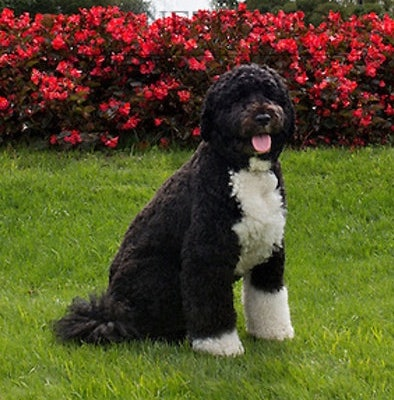

In [30]:
# We can access any sample's filepath
Image.open(a_sample.filepath)

In [ ]:
# Use the dataset's query_similar method
similar_view = bo_dataset.sort_by_similarity(
  a_sample.id,
  brain_key="vgg16_imagenet_cosine_similarity_index",
  k=5,  # Return top k similar images
  reverse=False  # Most similar first
)

# We save the view so that we can retrieve it later
bo_dataset.save_view('most_similar_to_sample', similar_view)

In [ ]:
similar_view

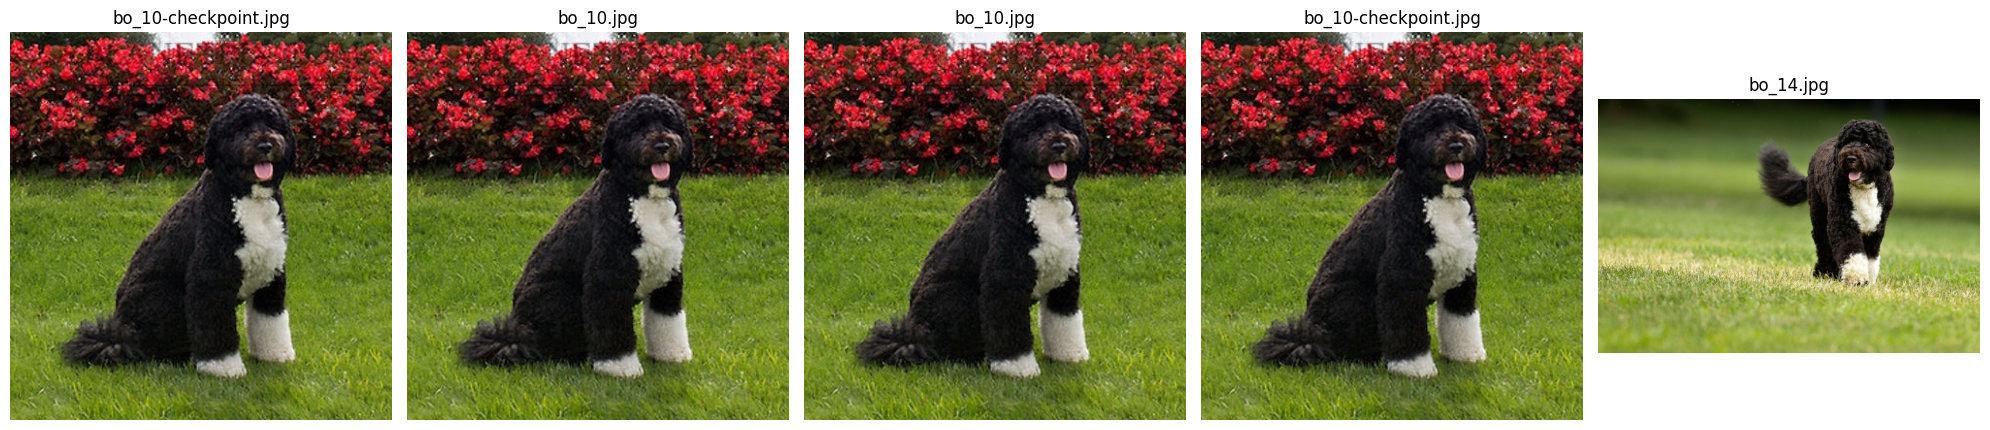

In [32]:
# Get the filepaths of the images in the similar_view
image_paths = [sample.filepath for sample in similar_view]

# Create a figure and a grid of subplots
num_images = len(image_paths)
fig, axes = plt.subplots(1, num_images, figsize=(20, 5)) # Adjust figsize as needed

# Handle case where there's only one image
if num_images == 1:
    axes = [axes]

# Iterate through the filepaths and plot each image
for ax, img_path in zip(axes, image_paths):
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(os.path.basename(img_path)) # Set title to filename
        ax.axis('off') # Hide axes
    except FileNotFoundError:
        print(f"Warning: File not found at {img_path}")
        ax.set_title("Image not found")
        ax.axis('off')

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

## Visualizing the Projected Embedding Space

Visualizing a 2D projection of the embedding space and coloring it with the class labels `bo` and `not_bo` allows us to see how difficult is for the model to perform the classification task. `


A clear separation between the 'bo' and 'not_bo' clusters in this 2D projection is a strong indicator that the features learned by VGG16 on ImageNet are already highly relevant for our task. This gives us high confidence that fine-tuning will be very effective, as the model won't have to learn to separate these classes from scratch.



In [33]:
visualization = fob.compute_visualization(bo_dataset,
                                          method='pca',
                                          brain_key='vgg_pca')
session.refresh()

Computing embeddings...


INFO:fiftyone.brain.internal.core.utils:Computing embeddings...


 100% |█████████████████| 344/344 [6.6s elapsed, 0s remaining, 82.7 samples/s]       


INFO:eta.core.utils: 100% |█████████████████| 344/344 [6.6s elapsed, 0s remaining, 82.7 samples/s]       


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...


In [34]:
testing_dataset.get_field_schema()

OrderedDict([('id', <fiftyone.core.fields.ObjectIdField at 0x7848bc93c860>),
             ('filepath',
              <fiftyone.core.fields.StringField at 0x7848bc93f7d0>),
             ('tags', <fiftyone.core.fields.ListField at 0x7848bcae7ec0>),
             ('metadata',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7848b0fce120>),
             ('created_at',
              <fiftyone.core.fields.DateTimeField at 0x7848bc93dd00>),
             ('last_modified_at',
              <fiftyone.core.fields.DateTimeField at 0x7848bca04cb0>),
             ('ground_truth',
              <fiftyone.core.fields.EmbeddedDocumentField at 0x7848bc93f980>)])

We can see that even if the VGG16 model doesn't know how to recognize the Portuguese Water Dog breed, the projected embedding space can cleanly separate the two classes.  This means that our new task should be easy to learn for the fine-tuned model.

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/bo_embeddings.png?raw=true)

In [35]:
print(session.url)

https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


## Using the pretrained VGG16 embeddings to remove duplicates between splits

 Images that are visually similar will have similar embeddings.

 By computing and comparing embeddings, we can find images that are essentially the same even if they have different file names or are slightly modified. Removing these duplicates is important to ensure that the training, validation, and test sets are truly independent. If duplicates exist across splits, the model's performance on the validation and test sets can be artificially inflated, leading to an overestimation of its ability.

In [36]:
bo_dataset

Name:        bo-dataset
Media type:  image
Num samples: 344
Persistent:  True
Tags:        []
Sample fields:
    id:                          fiftyone.core.fields.ObjectIdField
    filepath:                    fiftyone.core.fields.StringField
    tags:                        fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                    fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                  fiftyone.core.fields.DateTimeField
    last_modified_at:            fiftyone.core.fields.DateTimeField
    ground_truth:                fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    vgg16-imagenet-predictions:  fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    vgg16-imagenet-embeddings:   fiftyone.core.fields.VectorField
    fine_tuned_vgg16_prediction: fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Classification)
    

In [37]:
# Define your splits (e.g., via tags)
split_tags = ["train", "test", "validation"]

# Compute leaky splits
index = fob.compute_leaky_splits(bo_dataset,
                                 splits=split_tags,
                                 embeddings="vgg16-imagenet-embeddings")

# View the detected leaks
leaks = index.leaks_view()
session.view = leaks
print(session.url)

Computing duplicate samples...


INFO:fiftyone.brain.similarity:Computing duplicate samples...


Duplicates computation complete


INFO:fiftyone.brain.similarity:Duplicates computation complete


https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


In [39]:
# The original splits
test_set = index.split_views["test"]
train_set = index.split_views["train"]
val_set = index.split_views["validation"]


# The set with leaks removed
test_set_no_leaks = index.no_leaks_view(test_set)
train_set_no_leaks = index.no_leaks_view(train_set)
val_set_no_leaks = index.no_leaks_view(val_set)

# Save the leak-free views
bo_dataset.save_view("train_no_leaks", train_set_no_leaks, overwrite=True)
bo_dataset.save_view("validation_no_leaks", val_set_no_leaks, overwrite=True)
bo_dataset.save_view("test_no_leaks", test_set_no_leaks, overwrite=True)


session.view = test_set_no_leaks
print(session.url)

https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


## Inspecting the pretrained model's architecture

We will need to change the last layers of the model to output two instead of a thousand diffferent classes. We take a deep look at the layers in order to know where to do our changes.





In [40]:
# FiftyOne provides a wrapper for the VGG-16 model that simplifies usage
# for inference tasks.
model

In [41]:
# The PyTorch model is stored as an attribute inside the FiftyOne model wrapper
model._model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Inspecting the classes on which the model has been pre-trained on

Here we inspect the classes that the VGG16 model was trained on during its pre-training on the ImageNet dataset. This helps us understand what types of objects the model is already capable of recognizing and how relevant its existing knowledge is to our specific task of classifying "Bo" vs. "not Bo". Remember that the breed of Bo is 'Portuguese water dog'.

In [42]:
## Inspecting the weights of model and their associated metadata
weights = VGG16_Weights.IMAGENET1K_V1
dir(weights)

['__class__',
 '__doc__',
 '__eq__',
 '__hash__',
 '__module__',
 'get_state_dict',
 'meta',
 'name',
 'transforms',
 'url',
 'value',
 'verify']

Here we have the classes that are mapped to the 1000 output units of the model.
Notice that we have several breeds of dogs and cats in the categories of the trained model.
The breed of Bo (Portuguese Water Dog) is outside of the training distribution.

In [43]:
weights.meta['categories']

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

## Inspecting transformations applied to the input images

Understanding the transformations applied to the input images is important. These transformations, such as resizing, cropping, and normalization, prepare images for the VGG16 model. The model expects input images in a specific format and range based on its ImageNet training. Inspecting these transformations confirms correct data processing before the model receives it.





In [44]:
# These were the transformations applied to image during training
original_transforms = weights.transforms()
original_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [45]:
# This set of transforms is functionally equivalent as the one the comes with original_transforms.
original_transforms_in_order = transforms.Compose([
    # Turn the PIL image or NumPy array into a torch tensor for images
    transforms.ToImage(),
    # Converts images from the range [0, 255] to [0, 1]
    transforms.ToDtype(torch.float32, scale=True),
    # Resizes the image to 256x256 pixels
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    # These mean and standard deviation values come
    # from the RGB intensities from the ImageNet dataset.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    # Crops the image at the center, producing a 224x224 pixels image
    transforms.CenterCrop(224)
])

In [46]:
a_sample['filepath']

'/root/.cache/kagglehub/datasets/andandand/presidential-dog/versions/1/presidential_dog/train/bo/.ipynb_checkpoints/bo_10-checkpoint.jpg'

array([[[ 79,  83,  60],
        [ 73,  76,  55],
        [ 56,  59,  40],
        ...,
        [133, 133,  97],
        [137, 137, 101],
        [124, 124,  86]],

       [[ 49,  54,  31],
        [ 70,  75,  53],
        [ 74,  77,  58],
        ...,
        [ 84,  84,  50],
        [103, 103,  67],
        [103, 103,  65]],

       [[ 22,  32,   7],
        [ 47,  55,  32],
        [ 67,  70,  51],
        ...,
        [ 54,  54,  20],
        [ 80,  77,  44],
        [ 86,  83,  48]],

       ...,

       [[127, 134,  56],
        [145, 152,  72],
        [154, 164,  77],
        ...,
        [123, 146,  42],
        [112, 134,  36],
        [109, 130,  35]],

       [[126, 131,  51],
        [142, 150,  67],
        [150, 160,  73],
        ...,
        [128, 151,  45],
        [106, 128,  30],
        [102, 123,  30]],

       [[139, 144,  62],
        [144, 152,  67],
        [141, 149,  63],
        ...,
        [136, 159,  51],
        [108, 129,  34],
        [105, 126,  35]]], dtype=uint8)
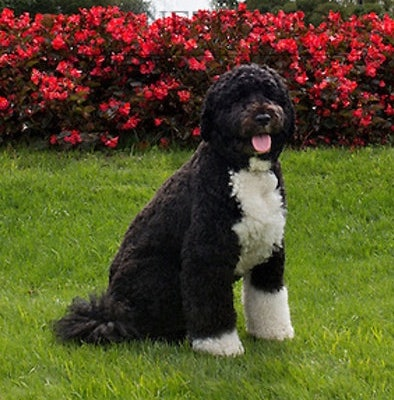

In [47]:
sample_image = Image.open(a_sample['filepath'])
np.array(sample_image)

In [48]:
transformed_input_tensor = original_transforms(sample_image)
transformed_input_tensor

tensor([[[-0.6965, -0.5767,  0.0056,  ..., -1.1589, -0.8849, -0.8849],
         [-0.7137, -0.0801,  0.8961,  ..., -0.7650, -1.0562, -1.2103],
         [ 0.1768,  0.6563,  0.9646,  ..., -0.5253, -0.9534, -1.2274],
         ...,
         [-0.4397, -0.4226, -0.4054,  ..., -0.0458, -0.0458, -0.0458],
         [-0.4397, -0.5082, -0.7308,  ..., -0.1657, -0.3883, -0.2856],
         [-0.5082, -0.6109, -0.3883,  ..., -0.1999, -0.3541, -0.2171]],

        [[-1.4755, -1.4230, -1.2304,  ..., -1.6856, -1.2479, -1.1779],
         [-1.6331, -1.5630, -1.0903,  ..., -1.3004, -1.4055, -1.5455],
         [-1.4755, -1.6331, -1.5630,  ..., -1.1253, -1.3880, -1.6331],
         ...,
         [ 0.1702,  0.1702,  0.1352,  ...,  0.4153,  0.4503,  0.4678],
         [ 0.1527,  0.0651, -0.1975,  ...,  0.2927,  0.1176,  0.2402],
         [ 0.0301, -0.0749,  0.1176,  ...,  0.2577,  0.1877,  0.3102]],

        [[-1.6127, -1.5256, -1.2119,  ..., -1.6302, -1.3687, -1.3687],
         [-1.6650, -1.4907, -0.8633,  ..., -1

In [49]:
transformed_input_tensor.shape

torch.Size([3, 224, 224])

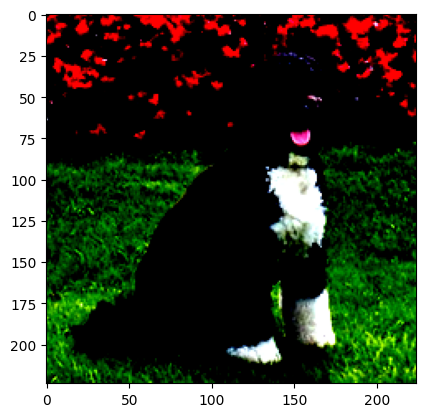

In [50]:
# The model evaluates the images after standard scaling, resizing and center cropping.
# The scaling changes the colors displayed by matplotlib.
# We need to run .permute(1, 2, 0) to reshape the tensor in Height, Width, Channels format for NumPy.
plt.imshow(transformed_input_tensor.permute(1,2,0));

FiftyOne has sent the model to the GPU device, if it's available. We can check this.

In [51]:
# Get the first parameters (weights) from the iterator
first_param = next(iter(model._model.parameters()))

# Access the device of the parameters. T
# This should print "cuda:0" if an NVIDIA GPU is available.
print(first_param.device)

cuda:0


In [52]:
# We reshape the input tensor to (1, 3, 224, 224) to specify a batch size
reshaped_input_tensor = transformed_input_tensor.reshape(1, 3, 224, 224)
# We send the tensor to the GPU
reshaped_input_tensor_gpu = reshaped_input_tensor.to(device)

In [53]:
# We obtain the logits (scores) out of the model
# Q: What would have happened if we send to the model reshaped_input_tensor?
# Q: What would have happened if we send to the model transformed_input_tensor?
logits = model._model(reshaped_input_tensor_gpu)

In [54]:
# Verify that we have as many logits as there are output units and classes on ImageNet.
# The first dimension corresponds to our batch size
logits.shape

torch.Size([1, 1000])

In [55]:
# Apply Softmax to convert logits to probabilities
probabilities = Fun.softmax(logits, dim=1)

# Get the predicted class index (the one with the highest probability)
predicted_class_index = torch.argmax(probabilities, dim=1).item()

# Get the corresponding label from the ImageNet categories
predicted_label = weights.meta["categories"][predicted_class_index]

print(f"The predicted class index is: {predicted_class_index}")
print(f"The predicted label is: {predicted_label}, with probability {probabilities[0][predicted_class_index].item():.2f}")


The predicted class index is: 267
The predicted label is: standard poodle, with probability 0.41


## Define augmentations for the training set




We define augmentations for the training set to artificially increase the size and variability of our training data. This helps the model generalize better to new, unseen images and reduces overfitting. These transformations can include things like rotation, scaling, and flipping. We visualize the augmentations to the dataset using FiftyOne to get a better sense of what is happening during training.

In [56]:
# Mark the training examples as original
train_view = bo_dataset.match_tags("train")
train_view.tag_samples("original")

Unlike the validation and test transformations, the training transformations can have random behavior. We see `RandomHorizontalFlip` and `RandomAffine` being used in this augmentation pipeline. We produce a new set of training images every time that we call it on our inputs. This allows the model to generalize better. For more possible augmentations that we can apply to our images, have a look at torch's [documentation](https://docs.pytorch.org/vision/0.9/transforms.html).

In [57]:
# Define augmentations for training images.
train_augmentations = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    #randomly flip the images left and right
    transforms.RandomHorizontalFlip(p=0.5),
    # Add random affine transformations: Shift, Scale, and Rotate
    transforms.RandomAffine(degrees=15,
                            translate=(0.1, 0.1),
                            scale=(0.95, 1.05),
                            interpolation=InterpolationMode.BILINEAR),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

### Create augmentation samples

The samples need to be saved as jpg files for us to visualize them on the FiftyOne app.

In [58]:
def denormalize_for_display(tensor, mean, std):
    """Reverse the normalization for visualization"""
    # Create a copy to avoid modifying the original tensor
    tensor_copy = tensor.clone()
    for t, m, s in zip(tensor_copy, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor_copy, 0, 1)

def create_augmentation_samples(view,
                                augmentations,
                                num_samples=50,
                                dataset_name="augmented_dataset"):
    """Create FiftyOne samples showing original and augmented versions using torchvision transforms"""

    # ImageNet normalization parameters (should match your augmentation pipeline)
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    if dataset_name in fo.list_datasets():
        aug_viz_dataset = fo.load_dataset(dataset_name)
        # Clear existing samples to recreate
        aug_viz_dataset.clear()
    else:
        aug_viz_dataset = fo.Dataset(dataset_name)

    sample_paths = view.values("filepath")[:num_samples]
    sample_labels = view.values("ground_truth.label")[:num_samples]

    for i, (path, label) in enumerate(zip(sample_paths, sample_labels)):
        # Load original image
        original_image = Image.open(path).convert('RGB')

        # Create sample for original image
        original_sample = fo.Sample(filepath=path)
        original_sample.tags = ["original"]
        original_sample["ground_truth"] = fo.Classification(label=label)
        original_sample["augmentation_type"] = "original"
        aug_viz_dataset.add_sample(original_sample)

        # Create 3 augmented versions
        for aug_idx in range(3):
            # Apply augmentation (this includes normalization)
            augmented_tensor = augmentations(original_image)

            # Denormalize for proper visualization
            display_tensor = denormalize_for_display(
                augmented_tensor,
                IMAGENET_MEAN,
                IMAGENET_STD
            )

            # Convert tensor back to PIL Image for saving
            # Now the tensor is properly in the range [0, 1]
            augmented_np = (display_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
            aug_image = Image.fromarray(augmented_np)

            # Save augmented image temporarily
            temp_path = f"/tmp/aug_torchvision_{i}_{aug_idx}.png"
            aug_image.save(temp_path)

            # Create FiftyOne sample for augmented image
            aug_sample = fo.Sample(filepath=temp_path)
            aug_sample.tags = ["augmented"]
            aug_sample["ground_truth"] = fo.Classification(label=label)
            aug_sample["augmentation_type"] = f"augmented_{aug_idx + 1}"
            aug_sample["original_sample_id"] = str(i)

            aug_viz_dataset.add_sample(aug_sample)

    return aug_viz_dataset

In [59]:
# Create the visualization dataset
aug_viz_dataset = create_augmentation_samples(
    train_view,
    train_augmentations,
    num_samples=50,
    dataset_name="augmented_dataset_denormalized_for_display"
)

In [60]:
print(f"Created visualization dataset with {len(aug_viz_dataset)} samples")
print(f"Original samples: {len(aug_viz_dataset.match_tags('original'))}")
print(f"Augmented samples: {len(aug_viz_dataset.match_tags('augmented'))}")

print(session.url)

Created visualization dataset with 200 samples
Original samples: 50
Augmented samples: 150
https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


![]()

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/original_augmented_bo.png?raw=true)

In [61]:
# Launch FiftyOne App to visualize the augmentations
session.view = aug_viz_dataset.view()

print(f"\nAugmentation Visualization URL: {session.url}")


Augmentation Visualization URL: https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


## Create the PyTorch Datasets and DataLoaders

In PyTorch, a `Dataset` is an abstract class representing a collection of data samples. It defines two main methods: `__len__`, which returns the number of samples in the dataset, and `__getitem__`, which returns a sample given an index. PyTorch `Dataset`s are designed to provide data samples in a format suitable for training models (typically as PyTorch tensors). They handle the loading and preprocessing of individual data points.

FiftyOne datasets, on the other hand, are designed for managing, visualizing, and analyzing datasets, particularly for computer vision tasks. They store metadata, labels, and links to the actual media files (images, videos). FiftyOne provides powerful tools for exploring data, querying subsets, evaluating models, and identifying issues in your dataset.

The key difference is their primary purpose:

*   **PyTorch Dataset:** Provides data samples for model training and evaluation, focusing on the format and structure needed by PyTorch models.
*   **FiftyOne Dataset:** Manages the dataset itself, providing tools for visualization, exploration, analysis, and organization of data and metadata.

You often use them together: A FiftyOne dataset can be used to manage and curate your data, and then you can create a PyTorch Dataset that wraps the FiftyOne dataset to feed data into a PyTorch model for training.

In [62]:
# Custom PyTorch Dataset class for our binary classification data
class CustomTorchImageDataset(torch.utils.data.Dataset):
    def __init__(self, fiftyone_dataset,
                 image_transforms=None,
                 label_map=None,
                 gt_field="ground_truth"):
        self.fiftyone_dataset = fiftyone_dataset
        self.image_paths = self.fiftyone_dataset.values("filepath")
        self.str_labels = self.fiftyone_dataset.values(f"{gt_field}.label")
        self.image_transforms = image_transforms

        # Define the label map for 'bo' and 'not_bo'
        if label_map is None:
            self.label_map = {"not_bo": 0, "bo": 1}
        else:
            self.label_map = label_map

        print(f"CustomTorchImageDataset initialized with {len(self.image_paths)} samples.")
        print(f"Label map: {self.label_map}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        try:
            # Open image as RGB (default for PIL.Image.open)
            image = Image.open(image_path)
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            # Return a dummy tensor and an invalid label in case of error
            # The shape should match the expected input shape after transforms
            # Assuming transforms output (C, H, W)
            # You might need to adjust the dummy tensor shape based on your transforms
            return torch.randn(3, 224, 224), torch.tensor(-1, dtype=torch.long)


        if self.image_transforms:
            image = self.image_transforms(image)

        label_str = self.str_labels[idx]
        label_idx = self.label_map.get(label_str, -1)
        if label_idx == -1:
            print(f"Warning: Label '{label_str}' not in label_map for image {image_path}")
            # Return an invalid label if the label is not in the map
            label_idx = -1


        return image, torch.tensor(label_idx, dtype=torch.long)

In [63]:
# Create a PyTorch dataset from the augmentation visualization dataset
aug_viz_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset=aug_viz_dataset,
    image_transforms=original_transforms_in_order, # Use the same transforms as for validation/testing
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

print("\nAugmentation Visualization PyTorch Dataset created:")
print(f"Number of samples: {len(aug_viz_torch_dataset)}")

CustomTorchImageDataset initialized with 200 samples.
Label map: {'not_bo': 0, 'bo': 1}

Augmentation Visualization PyTorch Dataset created:
Number of samples: 200


### Instantiate PyTorch datasets

The PyTorch dataset wraps together the training images and labels in a tuple of tensors. We present the image tensors to the model in batches. The labels are evaluated on the loss function to determine the quality of the predictions.  

In [64]:
# In FiftyOne, views and datasets can be used interchangebly
train_view = bo_dataset.match_tags("train")
val_view = bo_dataset.match_tags("validation")

print(f"Number of training samples: {len(train_view)}")
print(f"Number of validation samples: {len(val_view)}")

Number of training samples: 212
Number of validation samples: 72


In [65]:
len(train_set_no_leaks), len(val_set_no_leaks)

(208, 68)

In [66]:
# Use the leak-free views for creating PyTorch Datasets
train_view = train_set_no_leaks #bo_dataset.match_tags("train")
val_view = val_set_no_leaks #bo_dataset.match_tags("validation")

print(f"Number of training samples: {len(train_view)}")
print(f"Number of validation samples: {len(val_view)}")

# Define image transformations (using the original VGG16 transformations)
# You can add more augmentations here for training later
train_transforms = original_transforms_in_order # Use the corrected transforms
val_transforms = original_transforms_in_order # Use the corrected transforms

# Create instances of the CustomTorchImageDataset for train and validation
train_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset=train_view, #Experiment: compare with aug_viz_dataset
    image_transforms=train_augmentations, # Use training augmentations
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

val_torch_dataset = CustomTorchImageDataset(
    fiftyone_dataset=val_view,
    image_transforms=val_transforms,
    # label_map is automatically set to {"not_bo": 0, "bo": 1} by default
)

# Define batch size
batch_size = 8

# Create DataLoaders
train_dataloader = DataLoader(
    train_torch_dataset,
    batch_size=batch_size,
    shuffle=True, # Shuffle training data
    num_workers=2, # Use multiple workers for faster data loading
    pin_memory=True # Speed-up data transfer from CPU to GPU
)

val_dataloader = DataLoader(
    val_torch_dataset,
    batch_size=batch_size,
    shuffle=False, # Do not shuffle validation data
    num_workers=2, # Use multiple workers for faster data loading
    pin_memory=True # Speed-up data transfer from CPU to GPU

)

print("\nDataLoaders created:")
print(f"Train DataLoader: {len(train_dataloader)} batches of size {batch_size}")
print(f"Validation DataLoader: {len(val_dataloader)} batches of size {batch_size}")

Number of training samples: 208
Number of validation samples: 68
CustomTorchImageDataset initialized with 208 samples.
Label map: {'not_bo': 0, 'bo': 1}
CustomTorchImageDataset initialized with 68 samples.
Label map: {'not_bo': 0, 'bo': 1}

DataLoaders created:
Train DataLoader: 26 batches of size 8
Validation DataLoader: 9 batches of size 8


In [67]:
# This set of transforms is functionally equivalent as the one the comes with original_transforms.
original_transforms_in_order = transforms.Compose([
    # Turn the PIL image or NumPy array into a torch tensor for images
    transforms.ToImage(),
    # Converts images from the range [0, 255] to [0, 1]
    transforms.ToDtype(torch.float32, scale=True),
    # Resizes the image to 256x256 pixels
    transforms.Resize((256, 256), interpolation=InterpolationMode.BILINEAR),
    # These mean and standard deviation values come
    # from the RGB intensities from the ImageNet dataset.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
    # Crops the image at the center, producing a 224x224 pixels image
    transforms.CenterCrop(224)
])

In [68]:
def load_best_model(model_path, device):
    """
    Load the best saved model from training checkpoint.

    Args:
        model_path (Path): Path to the saved model state dict
        device (torch.device): Device to load the model on

    Returns:
        torch.nn.Module: Loaded model ready for inference
    """

    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    # Replace classifier to match our binary classification setup
    model.classifier = nn.Sequential(
        nn.Linear(in_features=25088, out_features=4096, bias=True),
        nn.ReLU(inplace=True),
        nn.Linear(in_features=4096, out_features=1, bias=True)
    )

    # Load the saved state dict
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()  # Set to evaluation mode

    print(f"Model loaded successfully from {model_path}")
    return model

##  Adapting VGG16 for Binary Classification





Since we are adapting the pre-trained VGG16 model for a new binary classification task ("Bo" vs. "not Bo"), we need to modify its final layers. The original model was trained to classify 1000 ImageNet categories. We replace the last classification layer with new layers suitable for our two classes. We also freeze the weights of the original VGG16 layers so that only the new layers are trained on our dataset, which is a common technique in transfer learning.

These changes could also be done on `model._model`(the vgg16 model that we used already). We keep things separate for consistency now.




In [69]:
new_model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
new_model


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Why Freeze Base Layers in Transfer Learning?

Freezing the initial layers of a pre-trained model offers several advantages:

1.  **Leverage Pre-trained Features:** Early layers in a network learn fundamental features like edges and textures. These are general and useful for many recognition tasks. Freezing these layers reuses these feature extractors.

2.  **Prevent Catastrophic Forgetting:** Training all layers on a small, new dataset can cause the model to forget the valuable general features learned from a large dataset. Freezing prevents this loss.

3.  **Focus Training on the New Task:** Freezing the base directs training to the new classification layers. This process is faster and requires less data than training the entire network.

4.  **Reduce Overfitting:** Training fewer parameters (only the new layers) lowers the risk of overfitting. The frozen base provides a stable feature representation.

In short, freezing base layers transfers a pre-trained model's general visual knowledge to a new task, achieving good performance with limited data.

In [70]:
# Freeze all base layers in the VGG16 model
for param in new_model.parameters():
    param.requires_grad = False

print("All VGG16 base layers have been frozen.")

All VGG16 base layers have been frozen.


## Trainable New Layers

When you add new layers to a PyTorch model (like replacing the classifier in this case), these new layers are initialized with random weights by default. These new layers are also **unfrozen** by default, meaning their `requires_grad` attribute is set to `True`. This ensures that they are included in the optimization process, and their weights are updated during training based on the calculated gradients.

In [71]:
## Replace the classifier layers
new_model.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=4096, bias=True),
    nn.ReLU(inplace=True),
    nn.Linear(in_features=4096, out_features=1, bias=True)
    )

In [72]:
# The new randomly initialized weights are unfrozen (trainable)
for param in new_model.classifier.parameters():
    print(param.requires_grad)

True
True
True
True


Just because we have a GPU in our Collab or local machine doesn't mean that we are using it. In PyTorch, we need to be explicit about this.

In [73]:
# Send the new model to the GPU, if available
new_model = new_model.to(device)

## Train and checkpoint the model

We train the modified VGG16 model on our "Bo" vs. "not Bo" dataset. Training involves feeding the data through the model, calculating the loss (how far off the predictions are), and updating the model's weights to minimize the loss. Checkpointing involves saving the model's weights periodically, especially when the model performs best on the validation set. This allows us to resume training later or use the best-performing model for inference.

### Define the loss function and optimizer

We define the loss function and optimizer that will be used to train the model. The loss function measures the difference between the model's predictions and the actual labels, guiding the training process to minimize this error. The optimizer is responsible for updating the model's weights based on the calculated gradients of the loss function.

#### Binary Cross Entropy Loss

In [74]:
# We use binary cross entropy loss from logits
# https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
ce_loss = torch.nn.BCEWithLogitsLoss()

The binary cross entropy loss (BCE) is defined as:

$$
\text{BCE}(y, \hat{y}) = - \frac{1}{N} \sum_{i=1}^N [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]
$$

where:
- $N$ is the number of samples in the batch
- $y_i$ is the true label for sample $i$ (0 or 1)
- $\hat{y}_i$ is the predicted probability for sample $i$

In PyTorch, [`BCEWithLogitsLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)receives inputs that correspond to the outputs of the final layer of the model. This set of outputs are called 'logits' and correspond to scores. These scores get turned into probabilities after going through a [Sigmoid activation function](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html).

#### The ADAM optimizer

In [75]:
# Define the optimizer (variant of stochastic gradient descent)
optimizer = Adam(new_model.parameters(),
                 lr=0.003, betas=(0.9, 0.999),
                 eps=1e-08, weight_decay=0)


The Adam optimizer is a popular optimization algorithm that is an extension to stochastic gradient descent. It adaptively estimates lower-order moments (mean and variance) of the gradients.

The settings used here are:

*   `lr=0.003`: This is the learning rate, which determines the step size at each iteration while moving towards a minimum of the loss function. A smaller learning rate requires more training epochs but can lead to a more stable model. A larger learning rate can converge faster but might overshoot the minimum.
*   `betas=(0.9, 0.999)`: These are the exponential decay rates for the first and second moment estimates. `beta1` (0.9) is for the first moment (mean) and `beta2` (0.999) is for the second moment (variance). These values control how quickly the algorithm forgets past gradients.
*   `eps=1e-08`: This is a small constant added to the denominator for numerical stability to prevent division by zero.
*   `weight_decay=0`: This is the L2 penalty (regularization). A value of 0 means no weight decay is applied. Weight decay helps to prevent overfitting by penalizing large weights.

### Defining a training epoch

The `train_epoch` function defines a single pass over the training dataset. In each epoch, the model processes the data in batches. For each batch, it calculates the loss, computes the gradients, and updates the model's weights using the optimizer to minimize the loss. The average loss over all batches in the epoch is returned.

In [76]:
def train_epoch(model, train_loader):
  batch_losses = []
  model.train()
  for images, labels in tqdm(train_loader, desc="Training: "):
      # We send the images and labels to the GPU, if available
      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      # Unsqueeze labels to match logits shape [batch_size, 1]
      loss_value = ce_loss(logits, labels.unsqueeze(1).float())
      # Clear gradients from previous iteration (PyTorch accumulates by default)
      optimizer.zero_grad()
      # Computes the gradients with backpropagation
      loss_value.backward()
      # Updates the weights
      optimizer.step()

      batch_losses.append(loss_value.item())

  train_loss = np.mean(batch_losses)
  return train_loss

### Defining a validation epoch

The `val_epoch` function defines a single pass over the validation dataset. In each epoch, the model processes the data in batches and calculates the loss to evaluate performance without updating the model's weights. The average loss over all batches in the epoch is returned.

In [77]:
def val_epoch(model, val_loader):
  batch_losses = []
  model.eval()
  with torch.inference_mode():
    for images, labels in tqdm(val_loader, desc="Validation: "):
      images = images.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(images)
      # Unsqueeze labels to match logits shape [batch_size, 1]
      loss_value = ce_loss(logits, labels.unsqueeze(1).float())
      batch_losses.append(loss_value.item())
  val_loss = np.mean(batch_losses)
  return val_loss

## Training loop

The training loop iterates over a specified number of epochs. In each epoch, it calls the `train_epoch` function to train the model on the training data and the `val_epoch` function to evaluate the model on the validation data. It keeps track of the training and validation losses and saves the model's state dictionary whenever a new best validation loss is achieved.

In [78]:
# Ensure reproducibility for the training process
set_seeds(51) # You can change this number to get different results

num_epochs = 10
train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0 # Counter for epochs without improvement
patience = 3 # Number of epochs to wait for improvement

# Define the path to save the model within your hard-drive
path = Path(os.getcwd()) # Feel free to change the path

model_save_path = './best_vgg16.pth'

for epoch in range(num_epochs):
    train_loss = train_epoch(new_model, train_dataloader)
    val_loss = val_epoch(new_model, val_dataloader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    # Check for improvement in validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Save the best model
        torch.save(new_model.state_dict(), model_save_path)
        print('Found and saved better weights for the model')
        epochs_no_improve = 0 # Reset counter
    else:
        epochs_no_improve += 1 # Increment counter

    # Check for early stopping
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {patience} epochs without improvement.")
        break



All random seeds set to 51 for reproducibility


Validation: 100%|██████████| 9/9 [00:00<00:00, 13.39it/s]


Epoch 1/10 - Train Loss: 1.9177 - Val Loss: 10.1341
Found and saved better weights for the model


Validation: 100%|██████████| 9/9 [00:00<00:00, 11.77it/s]


Epoch 2/10 - Train Loss: 0.2546 - Val Loss: 0.0000
Found and saved better weights for the model


...

Epoch 3/10 - Train Loss: 0.8131 - Val Loss: 6.6856


Validation: 100%|██████████| 9/9 [00:00<00:00, 13.20it/s]


Epoch 4/10 - Train Loss: 0.6188 - Val Loss: 0.0000


Validation: 100%|██████████| 9/9 [00:00<00:00, 13.32it/s]

Epoch 5/10 - Train Loss: 0.0000 - Val Loss: 154.3387
Early stopping triggered after 3 epochs without improvement.


## Visualizing training and validation losses



After training, we visualize the training and validation losses over epochs. This plot helps us monitor the model's learning progress, identify potential issues like overfitting (where training loss decreases but validation loss increases), and determine the optimal number of training epochs. The red line indicates the epoch where the best validation loss was achieved, and the model weights at this epoch are saved.


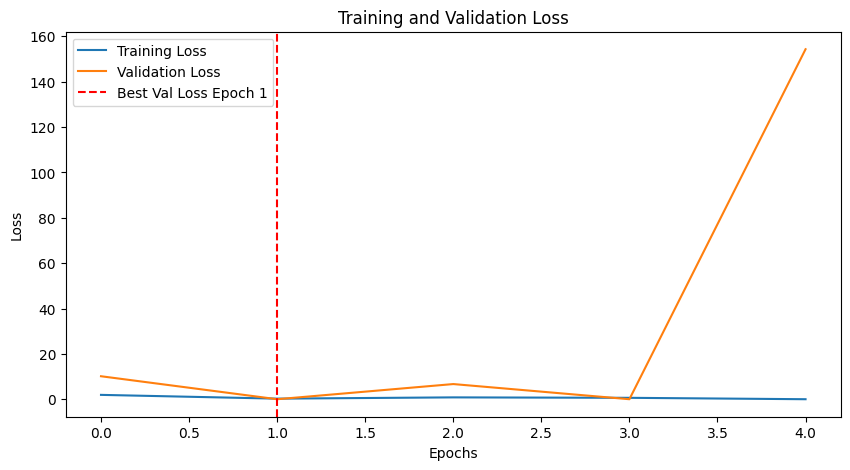

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

# Find the epoch with the best validation loss
best_epoch = np.argmin(val_losses)

# Add a vertical red line at the epoch with the best validation loss
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Val Loss Epoch {best_epoch}')
plt.legend()

plt.show()

## Apply predictions to the test set

After training and evaluating the model on the training and validation sets, we apply the best-performing model to the independent test set. This step assesses the model's ability to generalize to completely data and provides a final measure of its performance on the task of classifying "Bo" vs. "not Bo".

In [80]:
def load_best_model(model_path, device):
    """
    Load the best saved model from training checkpoint.

    Args:
        model_path (Path): Path to the saved model state dict
        device (torch.device): Device to load the model on

    Returns:
        torch.nn.Module: Loaded model ready for inference
    """

    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    # Replace classifier to match our binary classification setup
    model.classifier = nn.Sequential(
        nn.Linear(in_features=25088, out_features=4096, bias=True),
        nn.ReLU(inplace=True),
        nn.Linear(in_features=4096, out_features=1, bias=True)
    )

    # Load the saved state dict
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()  # Set to evaluation mode

    print(f"Model loaded successfully from {model_path}")
    return model



In [81]:
def predict_on_fiftyone_dataset(model, fo_dataset, transforms, device,
                               confidence_threshold=0.5, label_map=None):
    """
    Make predictions on a FiftyOne dataset and return predictions with confidence scores.

    Args:
        model (torch.nn.Module): Trained model
        fo_dataset (fiftyone.Dataset): FiftyOne dataset to predict on
        transforms: Image transformations to apply
        device (torch.device): Device for inference
        confidence_threshold (float): Threshold for binary classification
        label_map (dict): Mapping from class indices to labels

    Returns:
        list: List of dictionaries containing predictions and confidence scores
    """
    if label_map is None:
        label_map = {0: "not_bo", 1: "bo"}

    predictions = []

    # Get all image paths from the FiftyOne dataset
    image_paths = fo_dataset.values("filepath")

    print(f"Making predictions on {len(image_paths)} images...")

    with torch.no_grad():
        for image_path in tqdm(image_paths, desc="Predicting"):
            try:
                # Load and preprocess image
                image = Image.open(image_path).convert('RGB')
                image_tensor = transforms(image).unsqueeze(0).to(device)  # Add batch dimension

                # Make prediction
                logit = model(image_tensor)
                # Convert logit to probability
                probability = torch.sigmoid(logit).item()
                # Determine predicted class
                predicted_class_idx = 1 if probability >= confidence_threshold else 0
                predicted_label = label_map[predicted_class_idx]

                # Store prediction info
                prediction_info = {
                    'label': predicted_label,
                    'logit': logit,
                    'confidence': probability if predicted_class_idx == 1 else (1 - probability),
                    'bo_probability': probability,  # Probability of being Bo
                    'not_bo_probability': 1 - probability  # Probability of not being Bo
                }

                predictions.append(prediction_info)

            except Exception as e:
                print(f"Error processing {image_path}: {e}")
                # Add a default prediction for failed cases
                predictions.append({
                    'label': 'not_bo',  # Default to not_bo
                    'confidence': 0.0,
                    'bo_probability': 0.0,
                    'not_bo_probability': 1.0
                })

    return predictions



In [82]:
def add_predictions_to_fiftyone_dataset(fo_dataset, predictions,
                                        field_name="fine_tuned_vgg16_prediction"):
    """
    Add predictions to a FiftyOne dataset as Classification objects.

    Args:
        fo_dataset (fiftyone.Dataset): FiftyOne dataset to add predictions to
        predictions (list): List of prediction dictionaries
        field_name (str): Name of the field to store predictions
    """
    print(f"Adding predictions to FiftyOne dataset under field '{field_name}'...")

    # Iterate through samples and add predictions
    for sample, prediction in tqdm(zip(fo_dataset, predictions),
                                  total=len(fo_dataset),
                                  desc="Adding predictions"):
        # Create FiftyOne Classification object
        classification = fo.Classification(
            label=prediction['label'],
            confidence=prediction['confidence'],
            logits=prediction['logit'].cpu().numpy().flatten().tolist() # Add logit here
        )

        # Add additional metadata
        classification['bo_probability'] = prediction['bo_probability']
        classification['not_bo_probability'] = prediction['not_bo_probability']

        # Set the prediction field
        sample[field_name] = classification
        sample.save()

    print(f"Predictions successfully added to '{field_name}' field!")

## Inspect our output on the test set

In [83]:
# Use the leak-free test set for evaluation
test_view_no_leaks = test_set_no_leaks #bo_dataset.match_tags("test")

# Load the best saved model
best_model = load_best_model(model_save_path, device)

# Define transforms for the test set (same as validation)
test_transforms = original_transforms_in_order

# Make predictions on the leak-free test dataset
test_predictions = predict_on_fiftyone_dataset(
    best_model,
    test_view_no_leaks,
    test_transforms,
    device,
    # Use 0.5 as the threshold for binary classification probability
    confidence_threshold=0.5,
    # Explicitly define label map for clarity
    label_map={0: "not_bo", 1: "bo"}
)

# Add the predictions to the FiftyOne leak-free test dataset
add_predictions_to_fiftyone_dataset(test_view_no_leaks, test_predictions)

# Refresh the FiftyOne app session to see the new predictions
session.view = test_view_no_leaks.view()
session.refresh()
print(f"\nTest View URL: {session.url}")


Model loaded successfully from ./best_vgg16.pth
Making predictions on 56 images...


Predicting: 100%|██████████| 56/56 [00:00<00:00, 69.57it/s]


Adding predictions to FiftyOne dataset under field 'fine_tuned_vgg16_prediction'...


Adding predictions: 100%|██████████| 56/56 [00:00<00:00, 334.10it/s]


Predictions successfully added to 'fine_tuned_vgg16_prediction' field!

Test View URL: https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


In [84]:
# Check if any samples are missing predictions
samples_without_predictions = test_view_no_leaks.exists("fine_tuned_vgg16_prediction", False)
print(f"Samples without predictions: {len(samples_without_predictions)}")

# Check if any samples have None ground truth
samples_without_gt = test_view_no_leaks.exists("ground_truth", False)
print(f"Samples without ground truth: {len(samples_without_gt)}")

Samples without predictions: 0
Samples without ground truth: 0


In [85]:
# We can check that the predictions appear now on the samples
test_view_no_leaks.first()

<SampleView: {
    'id': '68d29d693dfbe3cdd83691c1',
    'media_type': 'image',
    'filepath': '/root/.cache/kagglehub/datasets/andandand/presidential-dog/versions/1/presidential_dog/test/bo/bo_21.jpg',
    'tags': ['test'],
    'metadata': <ImageMetadata: {
        'size_bytes': 59828,
        'mime_type': 'image/jpeg',
        'width': 612,
        'height': 399,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2025, 9, 23, 13, 15, 21, 673000),
    'last_modified_at': datetime.datetime(2025, 9, 23, 13, 35, 33, 197000),
    'ground_truth': <Classification: {
        'id': '68d29d696ba81a897c65018e',
        'tags': [],
        'label': 'bo',
        'confidence': None,
        'logits': None,
    }>,
    'vgg16-imagenet-predictions': <Classification: {
        'id': '68d2a1572245f428144efb34',
        'tags': [],
        'label': 'standard poodle',
        'confidence': 0.07592090964317322,
        'logits': None,
    }>,
    'vgg16-imagenet-embeddings': array([

We can go into the FiftyOne app to have a nice visual report on the performance of our classifier.

In [86]:
# Evaluate the predictions in the `predictions` field with respect to the
# labels in the `ground_truth` field
results = test_view_no_leaks.evaluate_classifications(
    "fine_tuned_vgg16_prediction",
    gt_field="ground_truth",
    eval_key="eval_simple",
)

# Print a classification report
results.print_report()

              precision    recall  f1-score   support

          bo       1.00      0.88      0.93        16
      not_bo       0.95      1.00      0.98        40

    accuracy                           0.96        56
   macro avg       0.98      0.94      0.95        56
weighted avg       0.97      0.96      0.96        56



In [87]:
session.view = test_view_no_leaks
print(session.url)

https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true



## Taking a Closer Look at the Test Set Output

To visually analyze our model's performance, we can use the FiftyOne App to filter and view the correct and incorrect predictions on our test set.

1.  In the FiftyOne App, locate the **"Samples"** tab.
2.  Click the **`+`** button to the right of the tab to open the view bar options.
3.  Under the **`Model Evaluation`** section, find the evaluation key you created (e.g., `eval_simple`).
4.  Click **`Split Horizontal`**. This will create two panels, allowing you to compare different subsets of your data next to the metric results of the evaluation.
5.  In one panel, you can now filter for **correctly labeled** images or for **incorrectly labeled** images by selecting the corresponding icons.

This side-by-side view is a powerful way to visually inspect where your model is succeeding and where it is failing. It's powerful to pair this with interpretability techniques like [GradCam](https://voxel51.com/blog/exploring-gradcam-and-more-with-fiftyone).

![](https://github.com/andandandand/practical-computer-vision/blob/main/images/bo_mistakes.png?raw=1)

We can also create these views programmatically.

In [89]:
from fiftyone import ViewField as F

# View correctly classified samples
correct_predictions = test_view_no_leaks.match(
    F("fine_tuned_vgg16_prediction.label") == F("ground_truth.label")
)
bo_dataset.save_view("correct_predictions", correct_predictions, overwrite=True)

# View incorrectly classified samples
incorrect_predictions = test_view_no_leaks.match(
    F("fine_tuned_vgg16_prediction.label") != F("ground_truth.label")
)
bo_dataset.save_view("incorrect_predictions", incorrect_predictions, overwrite=True)


## Save your work in a local directory with Google Drive

It's a good practice to save your work periodically. This section shows how to export your FiftyOne dataset to a local directory within your Google Drive.

In [90]:
bo_dataset.export(
    export_dir=str(save_path / "bo-dataset"),
    dataset_type=fo.types.FiftyOneDataset,
    split_types=["train", "validation", "test"],
    export_media=True # saves the images alongside our annotations

)

print(f"Dataset '{bo_dataset.name}' exported to {save_path / 'bo-dataset'}")

Directory '/gdrive/MyDrive/fiftyone-saved-work/bo-dataset' already exists; export will be merged with existing files


Ignoring unsupported parameter 'split_types'


Exporting samples...


INFO:fiftyone.utils.data.exporters:Exporting samples...


 100% |████████████████████| 344/344 [2.2m elapsed, 0s remaining, 1.5 docs/s]        


INFO:eta.core.utils: 100% |████████████████████| 344/344 [2.2m elapsed, 0s remaining, 1.5 docs/s]        


Dataset 'bo-dataset' exported to /gdrive/MyDrive/fiftyone-saved-work/bo-dataset


In [91]:
imported_dataset = fo.Dataset.from_dir(
    dataset_dir=str(save_path / "bo-dataset"),
    dataset_type=fo.types.FiftyOneDataset,  # or the specific type you exported
)

session.view = imported_dataset.view()
session.refresh()
print(f"\nImported Dataset URL: {session.url}")

Importing samples...


INFO:fiftyone.utils.data.importers:Importing samples...


 100% |█████████████████| 344/344 [15.3ms elapsed, 0s remaining, 22.5K samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 344/344 [15.3ms elapsed, 0s remaining, 22.5K samples/s]      



Imported Dataset URL: https://5151-gpu-t4-hm-2n0t19t6kzdoi-c.asia-east1-1.prod.colab.dev?polling=true


## Pushing to HuggingFace Hub

We can save the output of our work on HuggingFace. This will include all of our cleanup and predictions. Be sure to [set up your HuggingFace token for this](https://github.com/andandandand/practical-computer-vision/blob/main/docs/huggingface-account-and-token.md).

Check out the curated FiftyOne dataset at: https://huggingface.co/datasets/andandandand/bo_or_not

In [92]:
from fiftyone.utils.huggingface import push_to_hub

push_to_hub(bo_dataset,
            'bo_or_not',
            license='mit',
            chunk_size=100,
            exist_ok=True,
            )

Directory '/tmp/tmp2uevuoxn' already exists; export will be merged with existing files


Exporting samples...


INFO:fiftyone.utils.data.exporters:Exporting samples...


 100% |████████████████████| 344/344 [244.8ms elapsed, 0s remaining, 1.4K docs/s]     


INFO:eta.core.utils: 100% |████████████████████| 344/344 [244.8ms elapsed, 0s remaining, 1.4K docs/s]     
No files have been modified since last commit. Skipping to prevent empty commit.
Uploading media files in 4 batches of size 100: 100%|██████████| 4/4 [00:14<00:00,  3.53s/it]




### Follow-up Experiment: Transfer Learning vs. Training From Scratch

To truly understand the power of transfer learning, it's essential to compare it against the alternative: training a deep neural network from scratch. In this experiment, you will train a second VGG16 model, but this time, you will initialize it with random weights instead of the pre-trained ImageNet weights. You will then compare its performance and efficiency against the fine-tuned model.

#### Experimental Setup

We will evaluate two distinct training scenarios:

1.  **Transfer Learning (Fine-Tuned Model):**
    *   **Model:** VGG16 initialized with ImageNet pre-trained weights.
    *   **Trainable Layers:** Only the final, custom-added classifier layers are trained. The convolutional base layers remain frozen.
    *   **Learning Rate:** 0.003 (as used in the original notebook).

2.  **Training from Scratch:**
    *   **Model:** VGG16 initialized with random weights (`weights=None`).
    *   **Trainable Layers:** All layers in the network (both convolutional and fully-connected) are unfrozen and trained.
    *   **Learning Rate Scheduling:** Implementing variable learning rates during training will allow your model to learn better on this harder setup.  

For both experiments, you should use the same training, validation, and test datasets, the same loss function (`BCEWithLogitsLoss`), and the same optimizer (`Adam`). [Tracking your experiments with wandb](https://voxel51.com/blog/ml-menu-for-model-selection-hugging-face-weights-and-biases-fiftyone) is a great way to do this comparison.

#### Metrics for Comparison

To ensure a fair and comprehensive comparison, we will track the following metrics for both models:

*   **Final Test F1-Score:** The peak accuracy achieved on the test set.
*   **Training and Validation Losses:** The loss values at each epoch to visualize learning progress.
*   **Total Training Time:** The wall-clock time required to complete the training process.
*   **Epochs to Convergence:** The number of epochs it takes for the validation loss to stop improving.


### Syntax to setup our experiment

Try setting the weights to random values with `weights = None` and unfreeze the whole model. Compare the quality of the output.

Here is the syntax that you would use to train the weights from scratch and unfreeze all layers in the model.
```python
# Makes the model use fully random weights
new_model = vgg16(weights=None)


# Unfreeze all base layers in the VGG16 model
for param in new_model.parameters():
    param.requires_grad = True

print("All VGG16 base layers have been unfrozen.")
```

## Failure modes of the identification

Note that the model has not been tested against other Portuguese Water dogs. What would happen if you show it a picture of [Sunny](https://en.wikipedia.org/wiki/Sunny_(dog))? Try it!

Effectively, our binary classifier is just able to pick Portuguese Water Dogs from other breeds. For an effective identification system, we would need a more precise representatation of Bo. In computer vision, this particular problem is called 're-identification'.

The field or animal re-identification is highly active and fine-grained identification techniques that have been used on humans have been adapted to it. For example, [DogFaceNet](https://github.com/GuillaumeMougeot/DogFaceNet) uses the triplet loss to create embeddings that characterize an individual dog. In a follow-up blogpost, we will explore how to prepare our dataset to train a model to perform this precise identification.

## Takeaways

*   We have used  transfer learning to adapt a powerful, pre-trained model (VGG16) for a new, specialized task. This approach leverages existing knowledge from a large dataset (ImageNet) to build an effective classifier with a much smaller dataset.
*   We used FiftyOne to manage and visualize our image data. We explore the dataset with embeddings, create reproducible and clean data splits, and inspect our data augmentations, which provides us a clear understanding of our data at every step.
*   We modify the VGG16 architecture in PyTorch. We freeze the weights of the convolutional base layers and replace the final classifier with a new layer tailored for our binary classification problem.
*   We implement a complete training and validation loop. This includes creating custom PyTorch `Dataset`s, using `DataLoader`s to serve batches of images, defining a loss function (`BCEWithLogitsLoss`), and using an optimizer (`Adam`) to update model weights.
*   We evaluate the performance of our fine-tuned model. Using FiftyOne's evaluation capabilities, we generate a classification report and a confusion matrix to measure the model's accuracy on the unseen test set.




## References

* [FiftyOne documentation](https://docs.voxel51.com/)
* [Google's Machine Learning Glossary](https://developers.google.com/machine-learning/glossary)
* [PyTorch Tutorials](https://docs.pytorch.org/tutorials/)
* [Getting Started with FiftyOne YouTube Playlist](https://youtu.be/Iy_oYIrQefs?si=mHmR5sZAXJpbk0ZB)